<a href="https://colab.research.google.com/github/GalkaKG/AI_and_ML_projects/blob/main/open_api_ai_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐍 AI Python Support System

**Document:** *Python Cheat Sheet* – a concise Python 3 reference

This notebook implements an AI system that:
- Parses and indexes a PDF using **ChromaDB** + **OpenAI embeddings**
- Uses **OpenAI Structured Output** to detect the question and preferred response format
- Returns answers as **text**, **image** (DALL·E 3 generated), or **audio** (gTTS MP3)

**Models used:** `text-embedding-3-small` · `gpt-4o-mini` · `dall-e-3`

## Step 1 – Install Dependencies

In [1]:
!pip install -q openai chromadb pypdf gTTS pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/6

## Step 2 - API Key Setup



In [2]:
import os
from openai import OpenAI

# Load from Colab Secrets first, then fall back to environment variable
try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
except Exception:
    OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY')

if not OPENAI_API_KEY:
    raise ValueError(
        "❌ OPENAI_API_KEY not found!\n"
        "Add it via the 🔑 Secrets icon in Colab's left sidebar."
    )

client = OpenAI(api_key=OPENAI_API_KEY)
print("✅ OpenAI client initialised successfully")

✅ OpenAI client initialised successfully


## Step 3 – Upload the PDF

Upload `python_cheatsheet.pdf` (included in the ZIP) using the 📁 Files panel in Colab,  
or run the cell below to upload it interactively.

In [3]:
import os

PDF_PATH = "python_cheatsheet.pdf"

if not os.path.exists(PDF_PATH):
    # Interactive upload for Colab
    try:
        from google.colab import files
        print("📂 Please upload python_cheatsheet.pdf ...")
        uploaded = files.upload()
        PDF_PATH = list(uploaded.keys())[0]
        print(f"✅ Uploaded: {PDF_PATH}")
    except Exception:
        raise FileNotFoundError(
            f"❌ '{PDF_PATH}' not found.\n"
            "Place the PDF in the same directory as this notebook."
        )
else:
    size_kb = os.path.getsize(PDF_PATH) / 1024
    print(f"✅ PDF found: {PDF_PATH} ({size_kb:.1f} KB)")

📂 Please upload python_cheatsheet.pdf ...


Saving python_cheatsheet.pdf to python_cheatsheet.pdf
✅ Uploaded: python_cheatsheet.pdf


## Step 4 – Parse PDF and Split into Chunks

In [4]:
from pypdf import PdfReader

def load_and_chunk_pdf(pdf_path: str, chunk_size: int = 800, overlap: int = 100) -> list[dict]:
    """
    Reads every page of the PDF and splits text into overlapping chunks.

    Args:
        pdf_path:   Path to the PDF file.
        chunk_size: Characters per chunk.
        overlap:    Characters of overlap between consecutive chunks.

    Returns:
        List of dicts with keys: 'text', 'page', 'chunk_id'.
    """
    reader = PdfReader(pdf_path)
    chunks = []
    chunk_id = 0

    for page_num, page in enumerate(reader.pages):
        text = (page.extract_text() or "").strip()
        if not text:
            continue
        start = 0
        while start < len(text):
            chunk_text = text[start : start + chunk_size].strip()
            if chunk_text:
                chunks.append({
                    "text":     chunk_text,
                    "page":     page_num + 1,
                    "chunk_id": f"chunk_{chunk_id}"
                })
                chunk_id += 1
            start += chunk_size - overlap

    print(f"✅ {len(reader.pages)} pages parsed → {len(chunks)} chunks created")
    return chunks


chunks = load_and_chunk_pdf(PDF_PATH)
print(f"\n📄 Sample chunk (page {chunks[0]['page']}):\n{chunks[0]['text'][:300]}...")

✅ 8 pages parsed → 14 chunks created

📄 Sample chunk (page 1):
■ Python Cheat Sheet
A quick reference for Python 3 – variables, types, strings, collections, and control flow
1. Variables & Data Types
Python uses dynamic typing – no need to declare types explicitly.
x = 42             # int
pi = 3.14          # float
name = 'Alice'     # str
active = True      #...


## Step 5 – Build ChromaDB Vector Store with OpenAI Embeddings

Uses **`text-embedding-3-small`** – OpenAI's fastest and cheapest embedding model.  
All vectors are stored in an **in-memory ChromaDB** collection.

In [6]:
import time
import chromadb

EMBED_MODEL = "text-embedding-3-small"


class OpenAIEmbeddingFunction(chromadb.EmbeddingFunction):
    """ChromaDB-compatible embedding function backed by OpenAI text-embedding-3-small."""

    def __init__(self, openai_client):
        self._client = openai_client

    def __call__(self, input: list[str]) -> list[list[float]]:
        response = self._client.embeddings.create(
            model=EMBED_MODEL,
            input=input
        )
        # Return embeddings in the same order as input
        return [item.embedding for item in response.data]


chroma_client = chromadb.Client()
embedding_fn  = OpenAIEmbeddingFunction(client)

try:
    chroma_client.delete_collection("python_cheatsheet")
except Exception:
    pass

collection = chroma_client.create_collection(
    name="python_cheatsheet",
    embedding_function=embedding_fn
)

# OpenAI embeddings API accepts up to 2048 texts per request
# We batch in 20s to be safe and keep progress visible
BATCH_SIZE    = 20
total_batches = (len(chunks) - 1) // BATCH_SIZE + 1
print(f"📦 Indexing {len(chunks)} chunks in {total_batches} batch(es)...")

for i in range(0, len(chunks), BATCH_SIZE):
    batch = chunks[i : i + BATCH_SIZE]
    collection.add(
        documents=[c["text"]     for c in batch],
        ids=      [c["chunk_id"] for c in batch],
        metadatas=[{"page": c["page"]} for c in batch]
    )
    print(f"  ✓ Batch {i // BATCH_SIZE + 1}/{total_batches}")

print(f"\n✅ ChromaDB ready – {collection.count()} documents indexed")

📦 Indexing 14 chunks in 1 batch(es)...
  ✓ Batch 1/1

✅ ChromaDB ready – 14 documents indexed


## Step 6 – `retrieve_information(prompt)`

Embeds the question → semantic search in ChromaDB → top-5 chunks →  
GPT-4o-mini generates a grounded answer.

In [26]:
def retrieve_information(prompt: str) -> str:
    """
    Retrieves the most relevant passages from the PDF and generates
    a grounded answer using GPT-4o-mini.

    Args:
        prompt: A factual question about the document content.

    Returns:
        A string answer based exclusively on the document.
    """
    # 1. Embed the query
    query_embedding = client.embeddings.create(
        model=EMBED_MODEL,
        input=prompt
    ).data[0].embedding

    # 2. Retrieve top-5 most relevant chunks
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=min(3, collection.count())
    )
    context = "\n\n---\n\n".join(results["documents"][0])

    # 3. Generate a grounded answer with GPT-4o-mini
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a helpful Python programming assistant.\n"
                    "Answer the question using ONLY the document context provided.\n"
                    "If the answer is not in the context, say so clearly.\n"
                    "Be concise and use technical language suitable for developers."
                )
            },
            {
                "role": "user",
                "content": f"DOCUMENT CONTEXT:\n{context}\n\nQUESTION: {prompt}"
            }
        ],
        max_tokens=500,
        temperature=0.2
    )
    return response.choices[0].message.content.strip()

## Step 7 – Format Handlers (text / image / audio)

In [36]:
from PIL import Image, ImageDraw, ImageFont
from gtts import gTTS
from IPython.display import display, Audio, Image as IPImage


# ── TEXT ──────────────────────────────────────────────────────────
def format_as_text(answer: str) -> str:
    """Prints and returns the answer as plain text."""
    print("\n📝 TEXT RESPONSE")
    print("─" * 64)
    print(answer)
    print("─" * 64)
    return answer


# ── IMAGE ─────────────────────────────────────────────────────────
def format_as_image(answer: str, filename: str = "response_image.png") -> str:
    """
    Asks GPT-4o-mini to produce a JSON diagram spec,
    then renders it with Pillow as a clean technical diagram.
    """
    import json, re

    # Ask GPT to extract key concept boxes from the answer
    spec_response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": (
                    "Extract the key concept from the answer and return ONLY valid JSON "
                    "in this exact format, no markdown:\n"
                    "{\n"
                    "  \"title\": \"short title\",\n"
                    "  \"pairs\": [[\"key1\", \"value1\"], [\"key2\", \"value2\"], ...]\n"
                    "}\n"
                    "Max 6 pairs. Each key/value max 20 chars. "
                    "Use real Python examples from the answer."
                )
            },
            {"role": "user", "content": answer}
        ],
        max_tokens=200
    )

    raw = spec_response.choices[0].message.content.strip()
    raw = re.sub(r"```json|```", "", raw).strip()

    try:
        spec = json.loads(raw)
        pairs = spec.get("pairs", [])[:6]
        title = spec.get("title", "Concept")
    except Exception:
        pairs = []
        title = "Result"

    # ── Draw ─────────────────────────────────────────────────────
    W, H      = 620, 80 + len(pairs) * 54 + 40
    BG        = (250, 250, 250)
    BORDER    = (80,  80,  80)
    KEY_BG    = (220, 235, 255)
    VAL_BG    = (220, 255, 225)
    TITLE_BG  = (40,  60,  100)
    TEXT_COL  = (20,  20,  20)
    WHITE     = (255, 255, 255)

    img  = Image.new("RGB", (W, H), BG)
    draw = ImageDraw.Draw(img)

    try:
        font_title = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSansMono-Bold.ttf", 18)
        font_label = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",     13)
        font_code  = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSansMono-Bold.ttf", 13)
    except Exception:
        font_title = font_label = font_code = ImageFont.load_default()

    # Title bar
    draw.rectangle([0, 0, W, 46], fill=TITLE_BG)
    draw.text((W//2, 23), f"– {title} –", font=font_title, fill=WHITE, anchor="mm")

    # Column headers
    y = 54
    draw.text((160, y), "– keys –",   font=font_label, fill=BORDER, anchor="mm")
    draw.text((460, y), "– values –", font=font_label, fill=BORDER, anchor="mm")
    draw.line([(20, y+14), (W-20, y+14)], fill=(180,180,180), width=1)

    # Rows
    y = 78
    ROW_H  = 46
    BOX_W  = 160
    BOX_H  = 32
    ARROW  = "──►"

    for key, val in pairs:
        kx, vx = 80, 380   # left edges of key / value boxes

        # Key box
        draw.rectangle([kx, y, kx+BOX_W, y+BOX_H], fill=KEY_BG, outline=BORDER, width=1)
        draw.text((kx + BOX_W//2, y + BOX_H//2), f"'{key}'", font=font_code,
                  fill=TEXT_COL, anchor="mm")

        # Arrow
        draw.text((kx + BOX_W + 28, y + BOX_H//2), ARROW, font=font_label,
                  fill=BORDER, anchor="mm")

        # Value box
        draw.rectangle([vx, y, vx+BOX_W, y+BOX_H], fill=VAL_BG, outline=BORDER, width=1)
        draw.text((vx + BOX_W//2, y + BOX_H//2), f"'{val}'", font=font_code,
                  fill=TEXT_COL, anchor="mm")

        y += ROW_H

    # Outer border
    draw.rectangle([10, 10, W-10, H-10], outline=BORDER, width=1)

    img.save(filename)
    print("\n🖼️  IMAGE RESPONSE")
    display(IPImage(filename, width=500))
    return filename

# ── AUDIO ─────────────────────────────────────────────────────────
def format_as_audio(answer: str, filename: str = "response_audio.mp3") -> str:
    """
    Converts the answer to speech using gTTS (free, no API key needed).

    Args:
        answer:   The text to convert to speech.
        filename: Output file path.

    Returns:
        Path to the saved MP3 file.
    """
    tts = gTTS(text=answer, lang="en", slow=False)
    tts.save(filename)
    print("\n🔊 AUDIO RESPONSE")
    display(Audio(filename, autoplay=False))
    return filename


FORMAT_HANDLERS = {
    "text":  format_as_text,
    "image": format_as_image,
    "audio": format_as_audio,
}

print("✅ Format handlers ready (text / image / audio)")

✅ Format handlers ready (text / image / audio)


## Step 8 – `ask_ai(question)` with OpenAI Structured Output

Uses **OpenAI Structured Output** (Pydantic schema + `response_format`) to extract  
two fields from the user's natural language question:
- `prompt` – the clean factual question for the document
- `format` – `"text"` | `"image"` | `"audio"`

In [13]:
from pydantic import BaseModel
from typing import Literal


# ── Structured Output schema ──────────────────────────────────────
class UserIntent(BaseModel):
    """Structured output schema for parsing user questions."""
    prompt: str
    """The core factual question to search the document for (format preferences removed)."""
    format: Literal["text", "image", "audio"]
    """Desired response format inferred from the user's phrasing."""


INTENT_SYSTEM = (
    "You are an intent-parsing assistant. Extract exactly two things:\n"
    "1. 'prompt' – the core technical question (strip format preferences from it).\n"
    "2. 'format' – choose one:\n"
    "   • 'audio'  → user says: read, speak, tell me, out loud, audio, voice, narrate\n"
    "   • 'image'  → user says: image, picture, visual, show, display, infographic\n"
    "   • 'text'   → default for everything else"
)


def parse_user_intent(question: str) -> UserIntent:
    """
    Uses OpenAI Structured Output to extract the document query
    and desired response format from natural language.

    Args:
        question: Raw user question (may contain format hints).

    Returns:
        UserIntent with validated 'prompt' and 'format' fields.
    """
    completion = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": INTENT_SYSTEM},
            {"role": "user",   "content": question}
        ],
        response_format=UserIntent
    )
    return completion.choices[0].message.parsed


def ask_ai(question: str) -> str:
    """
    Main entry point. Parses the user's question with OpenAI Structured Output,
    retrieves the answer from the PDF via RAG, and returns the response
    in the requested format.

    Args:
        question: Natural-language question, optionally specifying output format.

    Returns:
        Answer string (text) or file path (image / audio).
    """
    print(f"\n{'═' * 64}")
    print(f"❓  {question}")
    print(f"{'═' * 64}")

    intent  = parse_user_intent(question)
    doc_q   = intent.prompt
    fmt     = intent.format

    print(f"🎯  Extracted prompt : {doc_q}")
    print(f"📤  Output format    : {fmt}")

    answer  = retrieve_information(doc_q)
    handler = FORMAT_HANDLERS.get(fmt, format_as_text)
    return handler(answer)


print("✅ ask_ai() ready")

✅ ask_ai() ready


## Step 9 – Test Cases

11 test cases covering **text** (×5), **image** (×2), and **audio** (×1).

In [14]:
# ── Test 1 – TEXT (implicit default) ─────────────────────────────
result_1 = ask_ai("What is the difference between a list and a tuple in Python?")


════════════════════════════════════════════════════════════════
❓  What is the difference between a list and a tuple in Python?
════════════════════════════════════════════════════════════════
🎯  Extracted prompt : What is the difference between a list and a tuple in Python?
📤  Output format    : text

📝 TEXT RESPONSE
────────────────────────────────────────────────────────────────
A list in Python is ordered and mutable, meaning its elements can be changed after creation. A tuple, on the other hand, is also ordered but immutable, meaning its elements cannot be changed once it is created.
────────────────────────────────────────────────────────────────


In [15]:
# ── Test 2 – TEXT ────────────────────────────────────────────────
result_2 = ask_ai("How do f-strings work and how are they different from format()?")


════════════════════════════════════════════════════════════════
❓  How do f-strings work and how are they different from format()?
════════════════════════════════════════════════════════════════
🎯  Extracted prompt : How do f-strings work and how are they different from format()?
📤  Output format    : text

📝 TEXT RESPONSE
────────────────────────────────────────────────────────────────
The document context does not provide information on how f-strings work or how they differ from the `format()` method.
────────────────────────────────────────────────────────────────


In [16]:
# ── Test 3 – TEXT ────────────────────────────────────────────────
result_3 = ask_ai("Explain how list comprehensions work in Python with an example")


════════════════════════════════════════════════════════════════
❓  Explain how list comprehensions work in Python with an example
════════════════════════════════════════════════════════════════
🎯  Extracted prompt : Explain how list comprehensions work in Python with an example
📤  Output format    : text

📝 TEXT RESPONSE
────────────────────────────────────────────────────────────────
List comprehensions in Python provide a concise way to create lists. They consist of an expression followed by a `for` clause and can include optional `if` clauses to filter items.

The general syntax is:
```python
[expression for item in iterable if condition]
```

Here's an example:
```python
squares = [x**2 for x in range(10) if x % 2 == 0]
```
In this example, `squares` will contain the squares of even numbers from 0 to 9. The `for` clause iterates over each number in the range, and the `if` clause filters out odd numbers, resulting in the list `[0, 4, 16, 36, 64]`.
────────────────────────────────

In [17]:
# ── Test 4 – TEXT ────────────────────────────────────────────────
result_4 = ask_ai("How does error handling work in Python? What are try, except, else and finally?")


════════════════════════════════════════════════════════════════
❓  How does error handling work in Python? What are try, except, else and finally?
════════════════════════════════════════════════════════════════
🎯  Extracted prompt : How does error handling work in Python? What are try, except, else and finally?
📤  Output format    : text

📝 TEXT RESPONSE
────────────────────────────────────────────────────────────────
Error handling in Python is managed using the `try`, `except`, `else`, and `finally` blocks. 

- **try**: This block contains code that may raise an exception. If an exception occurs, the control is transferred to the corresponding `except` block.
  
- **except**: This block handles the exception. You can specify different types of exceptions to catch, allowing for specific handling of different error types. For example, you can catch `ZeroDivisionError`, `TypeError`, or `ValueError`.

- **else**: This block runs if no exceptions were raised in the `try` block. It is u

In [18]:
# ── Test 5 – TEXT ────────────────────────────────────────────────
result_5 = ask_ai("What is the difference between *args and **kwargs in Python functions?")


════════════════════════════════════════════════════════════════
❓  What is the difference between *args and **kwargs in Python functions?
════════════════════════════════════════════════════════════════
🎯  Extracted prompt : What is the difference between *args and **kwargs in Python functions?
📤  Output format    : text

📝 TEXT RESPONSE
────────────────────────────────────────────────────────────────
In Python functions, `*args` allows you to pass a variable number of positional arguments, which are accessible as a tuple within the function. Conversely, `**kwargs` allows you to pass a variable number of keyword arguments, which are accessible as a dictionary within the function. This enables more flexible function signatures.
────────────────────────────────────────────────────────────────



════════════════════════════════════════════════════════════════
❓  Show me a visual summary of how dictionaries work in Python
════════════════════════════════════════════════════════════════
🎯  Extracted prompt : how dictionaries work in Python
📤  Output format    : image

🖼️  IMAGE RESPONSE


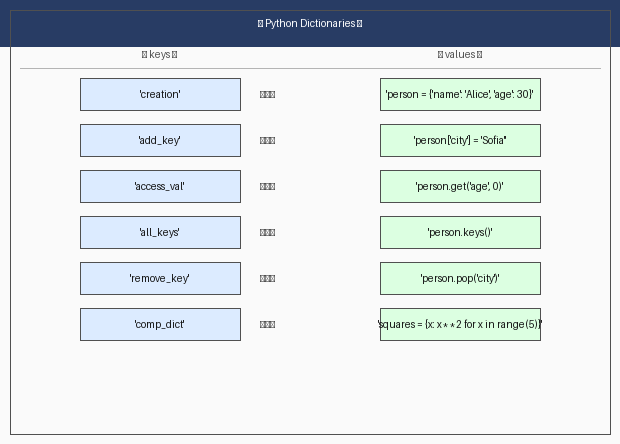

In [37]:
# ── Test 6 – IMAGE ('show' + 'visual') ───────────────────────────
result_6 = ask_ai("Show me a visual summary of how dictionaries work in Python")


════════════════════════════════════════════════════════════════
❓  Display an image explaining Python generators and how the yield keyword works
════════════════════════════════════════════════════════════════
🎯  Extracted prompt : Explain Python generators and how the yield keyword works
📤  Output format    : image

🖼️  IMAGE RESPONSE


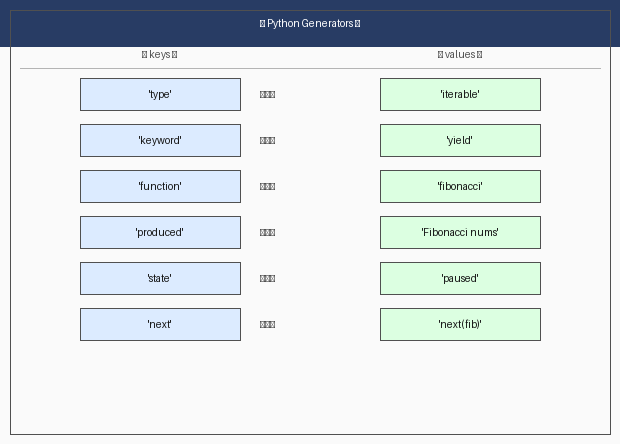

In [38]:
# ── Test 7 – IMAGE ('display') ───────────────────────────────────
result_7 = ask_ai("Display an image explaining Python generators and how the yield keyword works")

In [27]:
# ── Test 8 – AUDIO ('read out loud') ─────────────────────────────
result_8 = ask_ai("Please read out loud: how do virtual environments work and why should I use them?")


════════════════════════════════════════════════════════════════
❓  Please read out loud: how do virtual environments work and why should I use them?
════════════════════════════════════════════════════════════════
🎯  Extracted prompt : how do virtual environments work and why should I use them?
📤  Output format    : audio

🔊 AUDIO RESPONSE


In [31]:
# ── Test 9 – TEXT ────────────────────────────────────────────────
result_9 = ask_ai("What are Python decorators and how do you use @staticmethod and @classmethod?")


════════════════════════════════════════════════════════════════
❓  What are Python decorators and how do you use @staticmethod and @classmethod?
════════════════════════════════════════════════════════════════
🎯  Extracted prompt : What are Python decorators and how do you use @staticmethod and @classmethod?
📤  Output format    : text

📝 TEXT RESPONSE
────────────────────────────────────────────────────────────────
The document context does not provide information about Python decorators, @staticmethod, or @classmethod.
────────────────────────────────────────────────────────────────


In [32]:
# ── Test 10 – TEXT ───────────────────────────────────────────────
result_10 = ask_ai("How do you read and write JSON files in Python?")


════════════════════════════════════════════════════════════════
❓  How do you read and write JSON files in Python?
════════════════════════════════════════════════════════════════
🎯  Extracted prompt : How do you read and write JSON files in Python?
📤  Output format    : text

📝 TEXT RESPONSE
────────────────────────────────────────────────────────────────
To read and write JSON files in Python, you can use the `json` module. Here’s how:

**Writing a JSON file:**
```python
import json

data = {'key': 'value', 'num': 42}
with open('data.json', 'w') as f:
    json.dump(data, f, indent=2)  # Writes the dictionary to a JSON file
```

**Reading a JSON file:**
```python
import json

with open('data.json', 'r') as f:
    parsed = json.load(f)  # Reads the JSON file and parses it into a dictionary
```

This allows you to serialize a Python dictionary to a JSON file and deserialize it back to a dictionary from a JSON file.
────────────────────────────────────────────────────────────────


In [33]:
# ── Test 11 – AUDIO ('speak') ────────────────────────────────────
result_11 = ask_ai("Speak to me about the walrus operator and other Python quick tips")


════════════════════════════════════════════════════════════════
❓  Speak to me about the walrus operator and other Python quick tips
════════════════════════════════════════════════════════════════
🎯  Extracted prompt : What is the walrus operator and can you provide some quick tips for Python?
📤  Output format    : audio

🔊 AUDIO RESPONSE



════════════════════════════════════════════════════════════════
❓  Display an image showing how OOP inheritance works in Python
════════════════════════════════════════════════════════════════
🎯  Extracted prompt : How does OOP inheritance work in Python?
📤  Output format    : image

🖼️  IMAGE RESPONSE


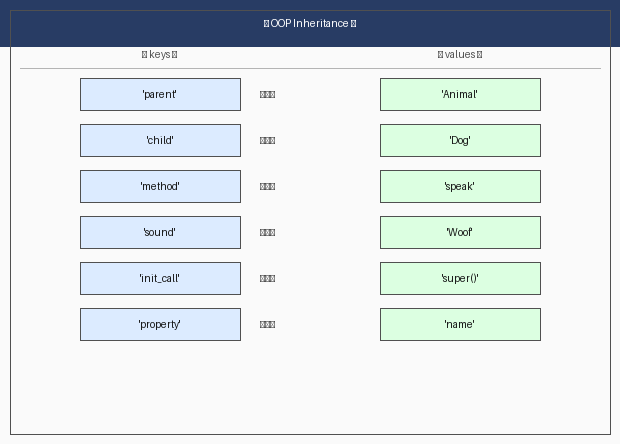

In [39]:
# ── Test 12 – IMAGE ('display') ──────────────────────────────────
result_12 = ask_ai("Display an image showing how OOP inheritance works in Python")

In [40]:
# ── Test 13 – TEXT ───────────────────────────────────────────────
result_13 = ask_ai("What built-in functions does Python provide and what do they do?")


════════════════════════════════════════════════════════════════
❓  What built-in functions does Python provide and what do they do?
════════════════════════════════════════════════════════════════
🎯  Extracted prompt : What built-in functions does Python provide and what do they do?
📤  Output format    : text

📝 TEXT RESPONSE
────────────────────────────────────────────────────────────────
Python provides several built-in functions, including:

1. **len(x)**: Returns the length of a sequence.  
   Example: `len([1,2,3])` → 3

2. **range(n)**: Generates a sequence of integers.  
   Example: `range(0,10,2)` → 0, 2, 4, ...

3. **enumerate()**: Returns index and value pairs from an iterable.  
   Example: `enumerate(['a','b'])`

4. **zip(a, b)**: Pairs up elements from multiple iterables.  
   Example: `zip([1,2],[3,4])` → (1,3), (2,4)

5. **map(f, it)**: Applies a function to each item in an iterable.  
   Example: `map(str,[1,2,3])`

6. **filter(f, it)**: Filters elements from an itera

## ✅ Summary

| # | Question topic | Format |
|---|----------------|--------|
| 1 | List vs Tuple | 📝 Text |
| 2 | f-strings vs format() | 📝 Text |
| 3 | List comprehensions | 📝 Text |
| 4 | Error handling (try/except/else/finally) | 📝 Text |
| 5 | *args vs **kwargs | 📝 Text |
| 6 | Dictionaries | 🖼️ Image |
| 7 | Generators & yield | 🖼️ Image |
| 8 | Virtual environments | 🔊 Audio |
| 9 | Decorators, @staticmethod & @classmethod | 📝 Text |
| 10 | Reading & writing JSON files | 📝 Text |
| 11 | Walrus operator & quick tips | 🔊 Audio |
| 12 | OOP inheritance | 🖼️ Image |
| 13 | Built-in functions | 📝 Text |

---

### 🏗️ Architecture

```
User Question (natural language)
        │
        ▼
parse_user_intent()       ← OpenAI Structured Output (Pydantic schema)
        │
        ├─ prompt ──► retrieve_information()
        │               ├─ OpenAI text-embedding-3-small  (embed query)
        │               ├─ ChromaDB                       (semantic search)
        │               └─ GPT-4o-mini                    (generate answer)
        │
        └─ format ──► "text"  → plain text
                      "image" → Pillow dark-theme PNG
                      "audio" → gTTS MP3
```

### 🛠️ Tech Stack

| Component | Tool |
|-----------|------|
| LLM | GPT-4o-mini |
| Embeddings | text-embedding-3-small |
| Structured Output | OpenAI Pydantic schema |
| Vector store | ChromaDB (in-memory) |
| Text-to-speech | gTTS (free, no key) |
| Image rendering | Pillow |
| PDF parsing | pypdf |